In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
ROOT = Path.cwd().parent

FEATURE_FILE = ROOT / "features/test_cohort_10_features.tsv"

print(ROOT)
print(FEATURE_FILE)

/home/ubuntu/ctdna-methylation-ml
/home/ubuntu/ctdna-methylation-ml/features/test_cohort_10_features.tsv


In [3]:
df = pd.read_csv(
    FEATURE_FILE,
    sep="\t"
)

df

,run_id,sample_id,ml_label,ELSA_0001,ELSA_0002,ELSA_0003,ELSA_0004,ELSA_0005,ELSA_0006,ELSA_0007,...,ELSA_2464,ELSA_2465,ELSA_2466,ELSA_2467,ELSA_2468,ELSA_2469,ELSA_2470,ELSA_2471,ELSA_2472,ELSA_2473
0,SRR15143359,BMD01123,0,0.131868,0.132964,0.024316,0.099476,0.036792,0.025404,0.087019,...,0.033333,0.029636,0.068871,0.087983,0.044534,0.030303,0.029126,0.246154,0.147887,0.075472
1,SRR15143291,BMD01062,0,0.082822,0.122137,0.031809,0.061321,0.049650,0.021875,0.081761,...,0.045289,0.034200,0.039486,0.058966,0.101284,0.036768,0.100809,0.152659,0.111111,0.040506
2,SRR9982411,BMD00623,1,0.097234,0.120722,0.029621,0.059701,0.043869,0.031234,0.095282,...,0.044858,0.032809,0.041643,0.050752,0.110360,0.046154,0.076669,0.128655,0.144928,0.069357
3,SRR9982564,BMD00840,0,0.095533,0.110018,0.019346,0.093633,0.039216,0.022645,0.088106,...,0.026421,0.027133,0.039720,0.038912,0.095207,0.038260,0.060872,0.126214,0.124792,0.061463
4,SRR9982549,BMD00404,1,0.097673,0.097809,0.011614,0.022863,0.024442,0.011818,0.040570,...,0.021066,0.014124,0.018450,0.032822,0.041416,0.034755,0.032434,0.093581,0.077701,0.030066
5,SRR9982526,BMD00122,0,0.157647,0.114478,0.020878,0.062374,0.038026,0.013158,0.068820,...,0.031298,0.039700,0.039379,0.046736,0.100699,0.043442,0.069121,0.121703,0.104381,0.061867
6,SRR9982384,BMD00186,1,0.034521,0.078228,0.027897,0.035511,0.045977,0.022631,0.071429,...,0.038618,0.025172,0.075893,0.067400,0.076566,0.046791,0.065997,0.120427,0.129496,0.060897
7,SRR9982899,BMD00326,1,0.147314,0.166468,0.030608,0.071795,0.041237,0.021576,0.057111,...,0.034972,0.037267,0.039553,0.024088,0.097202,0.052599,0.056011,0.130542,0.109890,0.046122
8,SRR9982493,BMD00494,0,0.128635,0.142336,0.022911,0.081197,0.038345,0.020802,0.080039,...,0.042028,0.029051,0.041292,0.034237,0.092283,0.039151,0.079266,0.142627,0.084586,0.062581


In [4]:
df["ml_label"].value_counts()

ml_label
0    5
1    4
Name: count, dtype: int64

In [5]:
feature_cols = [
    c for c in df.columns
    if c.startswith("ELSA_")
]

X = df[feature_cols]
y = df["ml_label"]

print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Controls:", (y == 0).sum())
print("Stage I cancer:", (y == 1).sum())

Samples: 9
Features: 2473
Controls: 5
Stage I cancer: 4


In [6]:
missing_per_sample = X.isna().sum(axis=1)

pd.DataFrame({
    "sample_id": df["sample_id"],
    "label": y,
    "missing_features": missing_per_sample,
    "missing_percent": missing_per_sample / X.shape[1] * 100
})

,sample_id,label,missing_features,missing_percent
0,BMD01123,0,16,0.646987
1,BMD01062,0,16,0.646987
2,BMD00623,1,16,0.646987
3,BMD00840,0,16,0.646987
4,BMD00404,1,16,0.646987
5,BMD00122,0,16,0.646987
6,BMD00186,1,16,0.646987
7,BMD00326,1,17,0.687424
8,BMD00494,0,16,0.646987


In [7]:
X.isna().sum().sum() / X.size * 100

np.float64(0.6514804331221639)

In [8]:
overall_missing = X.isna().sum().sum()
total_values = X.size
overall_missing_pct = overall_missing / total_values * 100

print(f"Missing values: {overall_missing:,}/{total_values:,}")
print(f"Overall missingness: {overall_missing_pct:.3f}%")
print(f"Observed values: {100 - overall_missing_pct:.3f}%")

Missing values: 145/22,257
Overall missingness: 0.651%
Observed values: 99.349%


In [9]:
sample_qc = pd.DataFrame({
    "run_id": df["run_id"],
    "sample_id": df["sample_id"],
    "label": y.map({0: "Control", 1: "Stage I cancer"}),
    "observed_features": X.notna().sum(axis=1),
    "missing_features": X.isna().sum(axis=1),
    "missing_percent": X.isna().mean(axis=1) * 100,
})

sample_qc.sort_values("missing_percent", ascending=False)


,run_id,sample_id,label,observed_features,missing_features,missing_percent
7,SRR9982899,BMD00326,Stage I cancer,2456,17,0.687424
0,SRR15143359,BMD01123,Control,2457,16,0.646987
1,SRR15143291,BMD01062,Control,2457,16,0.646987
3,SRR9982564,BMD00840,Control,2457,16,0.646987
2,SRR9982411,BMD00623,Stage I cancer,2457,16,0.646987
4,SRR9982549,BMD00404,Stage I cancer,2457,16,0.646987
5,SRR9982526,BMD00122,Control,2457,16,0.646987
6,SRR9982384,BMD00186,Stage I cancer,2457,16,0.646987
8,SRR9982493,BMD00494,Control,2457,16,0.646987


In [10]:
region_qc = pd.DataFrame({
    "region_id": feature_cols,
    "observed_samples": X.notna().sum(axis=0).values,
    "missing_samples": X.isna().sum(axis=0).values,
    "missing_percent": (X.isna().mean(axis=0) * 100).values,
})

print("Regions missing in all samples:",
      (region_qc["observed_samples"] == 0).sum())

region_qc.sort_values(
    ["missing_percent", "region_id"],
    ascending=[False, True]
).head(25)


Regions missing in all samples: 16


,region_id,observed_samples,missing_samples,missing_percent
941,ELSA_0942,0,9,100.000000
942,ELSA_0943,0,9,100.000000
943,ELSA_0944,0,9,100.000000
944,ELSA_0945,0,9,100.000000
945,ELSA_0946,0,9,100.000000
946,ELSA_0947,0,9,100.000000
947,ELSA_0948,0,9,100.000000
948,ELSA_0949,0,9,100.000000
949,ELSA_0950,0,9,100.000000
950,ELSA_0951,0,9,100.000000


In [11]:
sample_methylation = sample_qc.copy()
sample_methylation["mean_methylation"] = X.mean(axis=1, skipna=True)
sample_methylation["median_methylation"] = X.median(axis=1, skipna=True)

sample_methylation[
    ["run_id", "sample_id", "label", "mean_methylation", "median_methylation"]
].sort_values("mean_methylation")


,run_id,sample_id,label,mean_methylation,median_methylation
4,SRR9982549,BMD00404,Stage I cancer,0.060751,0.036016
5,SRR9982526,BMD00122,Control,0.075325,0.051227
3,SRR9982564,BMD00840,Control,0.076027,0.050963
0,SRR15143359,BMD01123,Control,0.078395,0.054015
8,SRR9982493,BMD00494,Control,0.078634,0.053528
7,SRR9982899,BMD00326,Stage I cancer,0.079913,0.053737
6,SRR9982384,BMD00186,Stage I cancer,0.084634,0.060224
1,SRR15143291,BMD01062,Control,0.084873,0.060185
2,SRR9982411,BMD00623,Stage I cancer,0.087781,0.063830


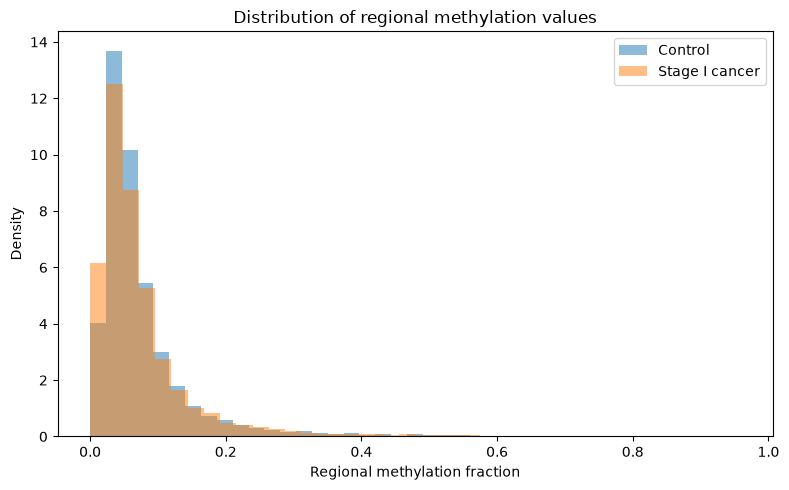

In [12]:
control_values = X.loc[y == 0].to_numpy().ravel()
cancer_values = X.loc[y == 1].to_numpy().ravel()

control_values = control_values[~np.isnan(control_values)]
cancer_values = cancer_values[~np.isnan(cancer_values)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(control_values, bins=40, density=True, alpha=0.5, label="Control")
ax.hist(cancer_values, bins=40, density=True, alpha=0.5, label="Stage I cancer")
ax.set_xlabel("Regional methylation fraction")
ax.set_ylabel("Density")
ax.set_title("Distribution of regional methylation values")
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
region_stats = []

for region in feature_cols:
    ctrl = X.loc[y == 0, region].dropna()
    ca = X.loc[y == 1, region].dropna()

    ctrl_mean = ctrl.mean() if len(ctrl) else np.nan
    ca_mean = ca.mean() if len(ca) else np.nan

    delta = (
        ca_mean - ctrl_mean
        if pd.notna(ctrl_mean) and pd.notna(ca_mean)
        else np.nan
    )

    region_stats.append({
        "region_id": region,
        "control_n": len(ctrl),
        "cancer_n": len(ca),
        "control_mean": ctrl_mean,
        "cancer_mean": ca_mean,
        "delta_methylation": delta,
        "abs_delta": abs(delta) if pd.notna(delta) else np.nan,
    })

region_stats = pd.DataFrame(region_stats)
comparable = region_stats.dropna(
    subset=["control_mean", "cancer_mean"]
).copy()

print("Comparable regions:", len(comparable))
print("Higher methylation in cancer:",
      (comparable["delta_methylation"] > 0).sum())
print("Lower methylation in cancer:",
      (comparable["delta_methylation"] < 0).sum())

comparable.sort_values("abs_delta", ascending=False).head(20)


Comparable regions: 2457
Higher methylation in cancer: 1149
Lower methylation in cancer: 1308


,region_id,control_n,cancer_n,control_mean,cancer_mean,delta_methylation,abs_delta
2156,ELSA_2157,5,4,0.127372,0.330973,0.203602,0.203602
776,ELSA_0777,5,4,0.421828,0.268516,-0.153311,0.153311
274,ELSA_0275,5,4,0.210934,0.073587,-0.137347,0.137347
1076,ELSA_1077,5,4,0.214183,0.349403,0.135221,0.135221
2332,ELSA_2333,5,4,0.070406,0.202838,0.132432,0.132432
523,ELSA_0524,5,4,0.232704,0.100864,-0.131840,0.131840
524,ELSA_0525,5,4,0.232704,0.100864,-0.131840,0.131840
2374,ELSA_2375,5,4,0.078980,0.208843,0.129862,0.129862
1425,ELSA_1426,5,4,0.179237,0.307594,0.128357,0.128357
2381,ELSA_2382,5,4,0.353795,0.469935,0.116140,0.116140


In [14]:
top_regions = (
    comparable
    .sort_values("abs_delta", ascending=False)
    .head(20)
    .copy()
)

top_regions

,region_id,control_n,cancer_n,control_mean,cancer_mean,delta_methylation,abs_delta
2156,ELSA_2157,5,4,0.127372,0.330973,0.203602,0.203602
776,ELSA_0777,5,4,0.421828,0.268516,-0.153311,0.153311
274,ELSA_0275,5,4,0.210934,0.073587,-0.137347,0.137347
1076,ELSA_1077,5,4,0.214183,0.349403,0.135221,0.135221
2332,ELSA_2333,5,4,0.070406,0.202838,0.132432,0.132432
523,ELSA_0524,5,4,0.232704,0.100864,-0.131840,0.131840
524,ELSA_0525,5,4,0.232704,0.100864,-0.131840,0.131840
2374,ELSA_2375,5,4,0.078980,0.208843,0.129862,0.129862
1425,ELSA_1426,5,4,0.179237,0.307594,0.128357,0.128357
2381,ELSA_2382,5,4,0.353795,0.469935,0.116140,0.116140


In [15]:
from statsmodels.stats.multitest import multipletests

test_rows = []

for region in feature_cols:
    ctrl = X.loc[y == 0, region].dropna()
    ca = X.loc[y == 1, region].dropna()

    if len(ctrl) >= 2 and len(ca) >= 2:
        stat, p = stats.mannwhitneyu(
            ca,
            ctrl,
            alternative="two-sided"
        )
    else:
        stat, p = np.nan, np.nan

    test_rows.append({
        "region_id": region,
        "U_statistic": stat,
        "p_value": p
    })

tests = pd.DataFrame(test_rows)

valid = tests["p_value"].notna()
tests.loc[valid, "fdr_bh"] = multipletests(
    tests.loc[valid, "p_value"],
    method="fdr_bh"
)[1]

region_analysis = comparable.merge(
    tests,
    on="region_id",
    how="left"
)

region_analysis.sort_values(
    ["p_value", "abs_delta"],
    ascending=[True, False]
).head(20)


,region_id,control_n,cancer_n,control_mean,cancer_mean,delta_methylation,abs_delta,U_statistic,p_value,fdr_bh
2365,ELSA_2382,5,4,0.353795,0.469935,0.116140,0.116140,20.0,0.015873,1.0
227,ELSA_0228,5,4,0.449543,0.336468,-0.113075,0.113075,0.0,0.015873,1.0
57,ELSA_0058,5,4,0.058108,0.156135,0.098027,0.098027,20.0,0.015873,1.0
1907,ELSA_1924,5,4,0.115622,0.047380,-0.068243,0.068243,0.0,0.015873,1.0
77,ELSA_0078,5,4,0.313885,0.247584,-0.066301,0.066301,0.0,0.015873,1.0
1462,ELSA_1479,5,4,0.251319,0.315577,0.064258,0.064258,20.0,0.015873,1.0
2103,ELSA_2120,5,4,0.030296,0.085127,0.054831,0.054831,20.0,0.015873,1.0
225,ELSA_0226,5,4,0.071916,0.024522,-0.047394,0.047394,0.0,0.015873,1.0
629,ELSA_0630,5,4,0.036322,0.077200,0.040879,0.040879,20.0,0.015873,1.0
457,ELSA_0458,5,4,0.076722,0.041698,-0.035025,0.035025,0.0,0.015873,1.0


In [16]:
usable_features = [
    c for c in feature_cols
    if X[c].notna().any()
]

X_pca = X[usable_features].copy()

# Median imputation for visualization only
X_pca = X_pca.fillna(X_pca.median(axis=0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": coords[:, 0],
    "PC2": coords[:, 1],
    "sample_id": df["sample_id"],
    "label": y.map({0: "Control", 1: "Stage I cancer"})
})

print(
    "Explained variance:",
    np.round(pca.explained_variance_ratio_ * 100, 2),
    "%"
)

pca_df


Explained variance: [29.56 16.22] %


,PC1,PC2,sample_id,label
0,0.943956,-52.604619,BMD01123,Control
1,22.873573,7.630564,BMD01062,Control
2,33.841184,0.959145,BMD00623,Stage I cancer
3,-10.017330,-0.761029,BMD00840,Control
4,-64.396278,11.432538,BMD00404,Stage I cancer
5,-7.897755,1.231854,BMD00122,Control
6,23.609730,24.404752,BMD00186,Stage I cancer
7,0.206651,2.631220,BMD00326,Stage I cancer
8,0.836269,5.075575,BMD00494,Control


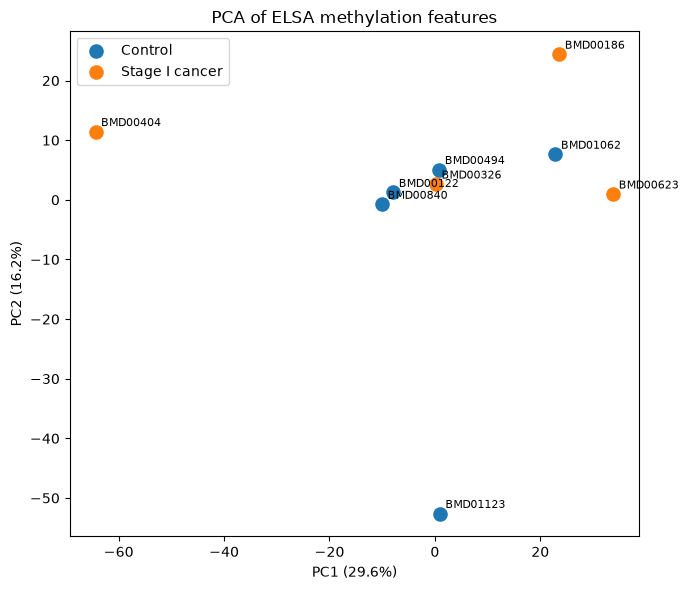

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))

for label in ["Control", "Stage I cancer"]:
    tmp = pca_df[pca_df["label"] == label]
    ax.scatter(
        tmp["PC1"],
        tmp["PC2"],
        label=label,
        s=90
    )

    for _, row in tmp.iterrows():
        ax.annotate(
            row["sample_id"],
            (row["PC1"], row["PC2"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8
        )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)"
)
ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)"
)
ax.set_title("PCA of ELSA methylation features")
ax.legend()
plt.tight_layout()
plt.show()


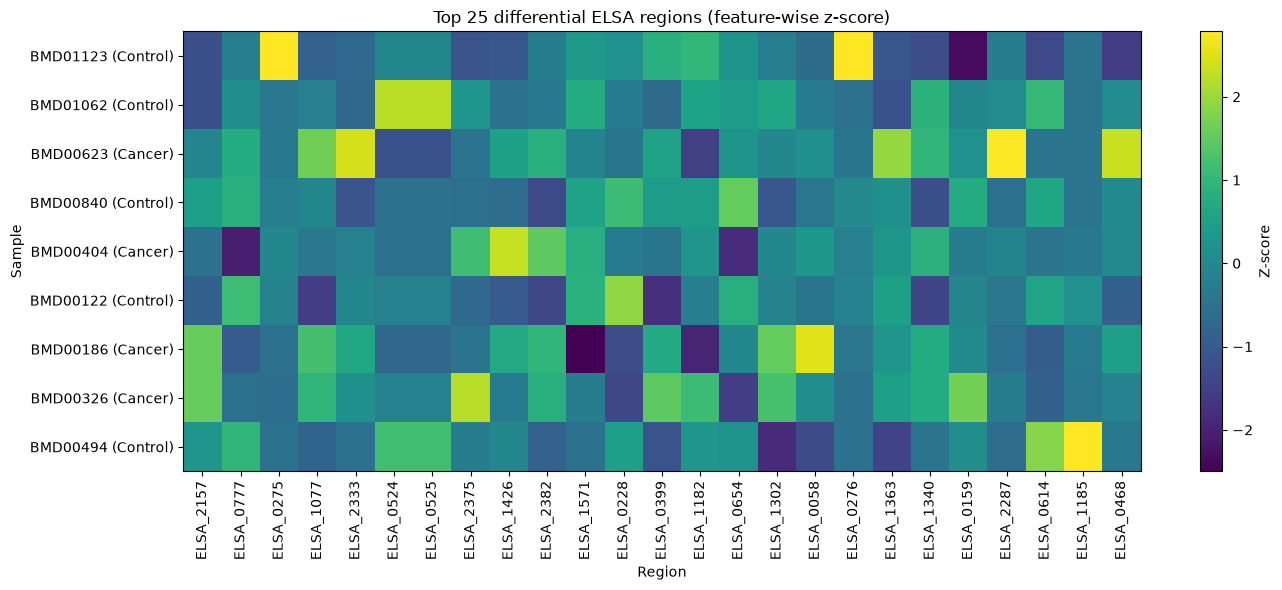

In [18]:
top25 = (
    comparable
    .sort_values("abs_delta", ascending=False)
    .head(25)["region_id"]
    .tolist()
)

heat = X[top25].copy()
heat = heat.fillna(heat.median(axis=0))

# Z-score each region to make relative differences easier to see
heat_z = (heat - heat.mean(axis=0)) / heat.std(axis=0, ddof=0)
heat_z = heat_z.replace([np.inf, -np.inf], np.nan).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heat_z.to_numpy(), aspect="auto")

ax.set_yticks(range(len(df)))
ax.set_yticklabels(
    [
        f"{sid} ({'Cancer' if lab == 1 else 'Control'})"
        for sid, lab in zip(df["sample_id"], y)
    ]
)

ax.set_xticks(range(len(top25)))
ax.set_xticklabels(top25, rotation=90)

ax.set_title("Top 25 differential ELSA regions (feature-wise z-score)")
ax.set_xlabel("Region")
ax.set_ylabel("Sample")

fig.colorbar(im, ax=ax, label="Z-score")
plt.tight_layout()
plt.show()


## Read-level and fragment features (step 05)

`X_methylation` averages every CpG call of a region into one number, which hides the few tumour-derived fragments in early-stage plasma. Step 05 (`scripts/05_read_features.py`) computes features per **fragment** instead, and step 07 writes them to `notebooks/data/X_<feature>.tsv`:

| Feature set | Per region | Why |
|---|---|---|
| `meth` | methylated / all CpG calls, **without the end-repair artifact** | clean version of `X_methylation` |
| `frac_meth` | fragments (≥ 3 CpGs) with ≥ 80% methylated CpGs | rare hypermethylated tumour fragments |
| `frac_meth_short` | the same among fragments ≤ 150 bp | ctDNA is shorter than normal cfDNA |
| `mhl` | methylation haplotype load | co-methylation along the fragment |
| `pdr` | fragments with mixed methylated / unmethylated CpGs | epigenetic heterogeneity |
| `entropy` | entropy of the 4-CpG patterns | the same, as pattern diversity |
| `frac_short` | fragments ≤ 150 bp | fragmentomics, independent of methylation |
| `X_sample` (per sample) | median fragment length, short fraction, short/long ratio | genome-wide fragmentomics |

The checks below, for every feature set:

1. **Quality**: coverage, missingness, sparsity, supporting fragments.
2. **Technical confounding**: correlation with read depth, DNA input and the end-repair artifact.
3. **Redundancy**: how much a set repeats `X_methylation`.
4. **Univariate signal**: per-region AUC against an exact label-permutation null.
5. **Model impact**: cross-validated AUC, with a permutation p-value.

> [!WARNING]
> With 9 samples (4 vs. 5) every number here is very noisy. The section runs unchanged on a larger cohort; on 9 samples, read it as a test of the features and the code, not as evidence that a feature works.

In [19]:
from pathlib import Path
from itertools import combinations
from math import comb
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy import stats

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 42
MODE = "custom"     # "custom" or "nfcore": which dataset of step 07 to read

ROOT = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent
SUB = "" if MODE == "custom" else MODE
DATA_DIR = ROOT / "notebooks/data" / SUB
FEATURES_DIR = ROOT / "features" / SUB
OUT_DIR = ROOT / "results/feature_eval" / SUB
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_COLORS = {0: "#2a78d6", 1: "#eb6834"}          # control, cancer
CLASS_NAMES = {0: "Control", 1: "Stage I cancer"}
MUTED = "#8a8985"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
})

info = json.loads((DATA_DIR / "dataset_info.json").read_text())
samples = pd.read_csv(DATA_DIR / "samples.tsv", sep="\t").set_index("sample_id")
y = samples["ml_label"].astype(int)

SETS = {"methylation": pd.read_csv(DATA_DIR / "X_methylation.tsv", sep="\t", index_col="sample_id")}
for name in info["read_feature_sets"]:
    SETS[name] = pd.read_csv(DATA_DIR / f"X_{name}.tsv", sep="\t", index_col="sample_id")

X_sample = pd.read_csv(DATA_DIR / "X_sample.tsv", sep="\t", index_col="sample_id")

# Hard alignment checks: a silent row mismatch would invalidate everything
for X in [*SETS.values(), X_sample]:
    assert X.index.equals(y.index)

SUPPORT = {name: v["support"] for name, v in info["read_feature_sets"].items()}

def support_matrix(count):
    """Fragment counts behind a read-level feature (written by step 05)."""
    df = pd.read_csv(FEATURES_DIR / f"{info['cohort']}_read_{count}.tsv", sep="\t")
    return df.set_index("sample_id").drop(columns=["run_id", "ml_label"]).loc[y.index]

print(f"Mode: {MODE}   samples: {len(y)}   " +
      ", ".join(f"{CLASS_NAMES[k]}={v}" for k, v in y.value_counts().sort_index().items()))
print("Feature sets:", ", ".join(f"{k} ({v.shape[1]})" for k, v in SETS.items()),
      f"| X_sample ({X_sample.shape[1]})")

Mode: custom   samples: 9   Control=5, Stage I cancer=4
Feature sets: methylation (2452), meth (2454), frac_meth (1369), frac_meth_short (32), mhl (2254), pdr (2149), entropy (2149), frac_short (2440) | X_sample (3)


### 1. Quality

- `missing_%`: values masked by step 07 (too few supporting fragments) after region filtering.
- `zero_%`: exact zeros. `frac_meth` is expected to be sparse: in healthy plasma these regions are unmethylated, so a methylated fragment is rare. That rarity is the point of the feature, but it needs depth.
- `median_support`: CpG calls (`methylation`, `meth`) or fragments behind each value.

In [20]:
coverage = pd.read_csv(DATA_DIR / "X_coverage.tsv", sep="\t", index_col="sample_id")

rows = []
for name, X in SETS.items():
    v = X.to_numpy().ravel()
    v = v[~np.isnan(v)]
    support = coverage if name == "methylation" else support_matrix(SUPPORT[name])
    rows.append({
        "feature_set": name,
        "regions_kept": X.shape[1],
        "missing_%": X.isna().mean().mean() * 100,
        "zero_%": (v == 0).mean() * 100,
        "median": np.median(v),
        "p95": np.percentile(v, 95),
        "median_support": np.nanmedian(support[X.columns].to_numpy()),
    })

quality = pd.DataFrame(rows).set_index("feature_set")
quality.round(4)

,regions_kept,missing_%,zero_%,median,p95,median_support
feature_set,,,,,,
methylation,2452,0.0725,0.3174,0.0537,0.2216,1311.5
meth,2454,0.0181,2.2099,0.0289,0.1875,1252.0
frac_meth,1369,0.2191,71.5390,0.0000,0.0370,163.0
frac_meth_short,32,6.5972,83.2714,0.0000,0.0435,27.0
mhl,2254,0.3155,1.4786,0.0004,0.0193,151.0
pdr,2149,0.4550,1.8646,0.1790,0.5333,143.0
entropy,2149,0.4550,1.8387,0.1591,0.5006,143.0
frac_short,2440,0.1730,11.9560,0.0298,0.1034,178.0


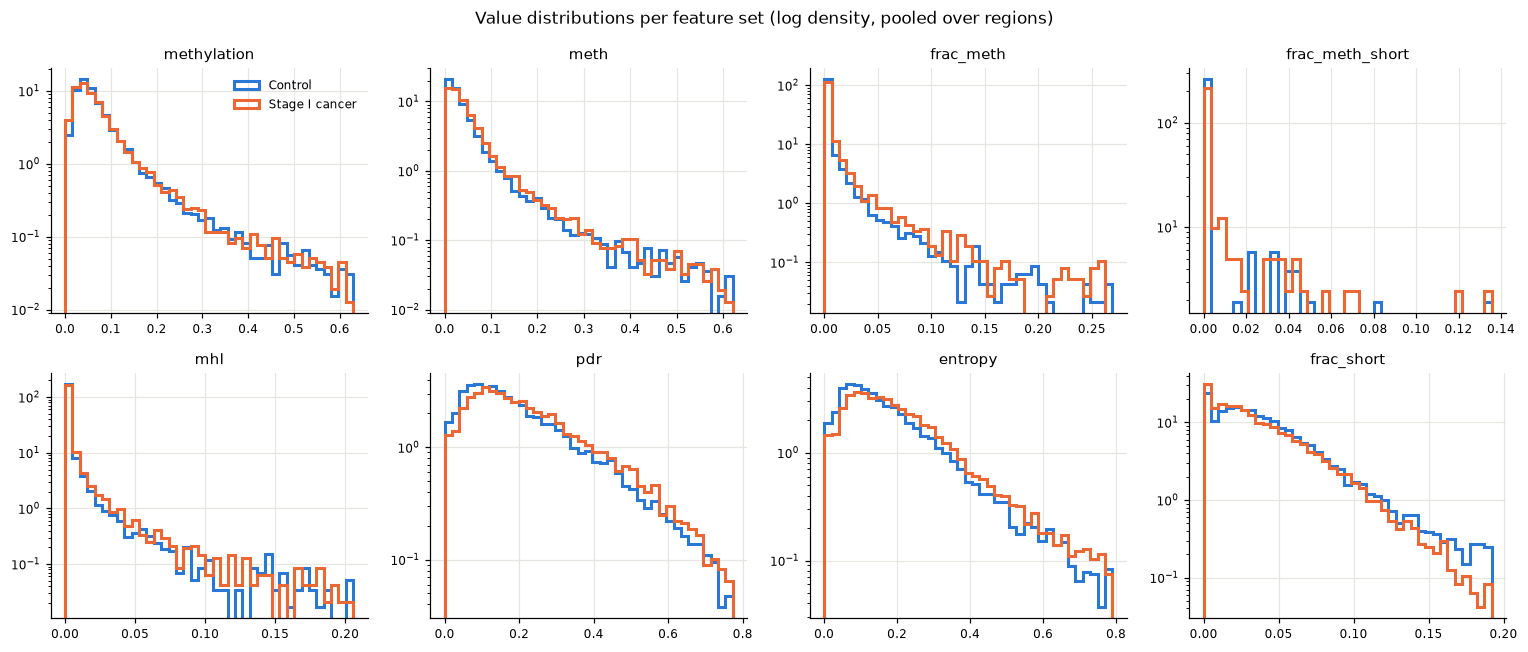

In [21]:
n = len(SETS)
ncols = 4
fig, axes = plt.subplots(int(np.ceil(n / ncols)), ncols, figsize=(14, 3 * np.ceil(n / ncols)))

for ax, (name, X) in zip(axes.ravel(), SETS.items()):
    values = X.to_numpy()
    bins = np.linspace(np.nanmin(values), np.nanpercentile(values, 99.5), 40)
    for label in (0, 1):
        v = values[(y == label).to_numpy()].ravel()
        ax.hist(v[~np.isnan(v)], bins=bins, density=True, histtype="step",
                linewidth=2, color=CLASS_COLORS[label], label=CLASS_NAMES[label])
    ax.set_title(name, fontsize=10)
    ax.set_yscale("log")
    ax.tick_params(labelsize=8)

for ax in axes.ravel()[n:]:
    ax.axis("off")

axes.ravel()[0].legend(frameon=False, fontsize=8)
fig.suptitle("Value distributions per feature set (log density, pooled over regions)", fontsize=11)
fig.tight_layout()
plt.show()

### 2. Technical confounding

A feature set that follows read depth, DNA input or library artifacts more than the label will mislead any model. For each set, the per-sample mean is correlated (Spearman) with:

- `depth`: median region depth (step 04)
- `fragments`: proper-pair fragments in the BAM
- `dna_input`: DNA input (ng)
- `artifact`: `r2_end_ch_meth`, the methylation of the filled-in R2 end. It measures how strongly the end-repair artifact affects a library.
- `label`: for comparison

With 9 samples, |ρ| must be above ~0.68 to reach p < 0.05; treat large values as warnings, not proof.

In [22]:
technical = pd.DataFrame({
    "depth": samples["median_region_depth"],
    "fragments": samples["n_fragments"],
    "dna_input": samples["dna_input_ng"],
    "artifact": samples["r2_end_ch_meth"],
    "label": y,
})

per_sample = {name: X.mean(axis=1) for name, X in SETS.items()}
per_sample.update({col: X_sample[col] for col in X_sample.columns})

confounding = pd.DataFrame({
    name: {f"rho_{col}": stats.spearmanr(values, technical[col])[0] for col in technical}
    for name, values in per_sample.items()
}).T

samples[["submission_series", "median_region_depth", "n_fragments",
         "ch_filtered_fraction", "r2_end_ch_meth"]].assign(label=y.map(CLASS_NAMES))

,submission_series,median_region_depth,n_fragments,ch_filtered_fraction,r2_end_ch_meth,label
sample_id,,,,,,
BMD01123,SRR151,547.0,1193375,0.000604,0.710517,Control
BMD01062,SRR151,922.0,1036873,0.001053,0.674211,Control
BMD00623,SRR998,1727.0,1689476,0.000433,0.641757,Stage I cancer
BMD00840,SRR998,1650.0,2044215,0.000395,0.667397,Control
BMD00404,SRR998,5496.0,5189360,0.000322,0.077705,Stage I cancer
BMD00122,SRR998,2299.0,1886356,0.000611,0.658510,Control
BMD00186,SRR998,919.0,1385315,0.000670,0.709252,Stage I cancer
BMD00326,SRR998,779.0,889833,0.000735,0.710975,Stage I cancer
BMD00494,SRR998,1488.0,1534688,0.000918,0.638520,Control


In [23]:
confounding.round(2)

,rho_depth,rho_fragments,rho_dna_input,rho_artifact,rho_label
methylation,-0.42,-0.62,0.27,0.32,0.26
meth,-0.02,-0.25,0.33,-0.07,0.69
frac_meth,-0.17,-0.12,0.13,0.18,0.61
frac_meth_short,0.08,0.32,0.43,-0.03,0.52
mhl,-0.23,-0.15,0.18,0.17,0.43
pdr,0.23,-0.02,0.46,-0.23,0.52
entropy,0.30,0.02,0.46,-0.30,0.52
frac_short,0.22,0.35,-0.38,-0.35,-0.35
frag_median,-0.26,-0.34,0.31,0.46,0.26
frag_frac_short,0.30,0.35,-0.34,-0.40,-0.26


**The end-repair artifact in `X_methylation`.** Step 04 counts every CpG call, including the artifact calls at the filled-in R2 end; `meth` drops them. Below is the per-sample difference between the two and how it follows the artifact strength. If the difference tracks `r2_end_ch_meth`, `X_methylation` carries a library-specific offset.

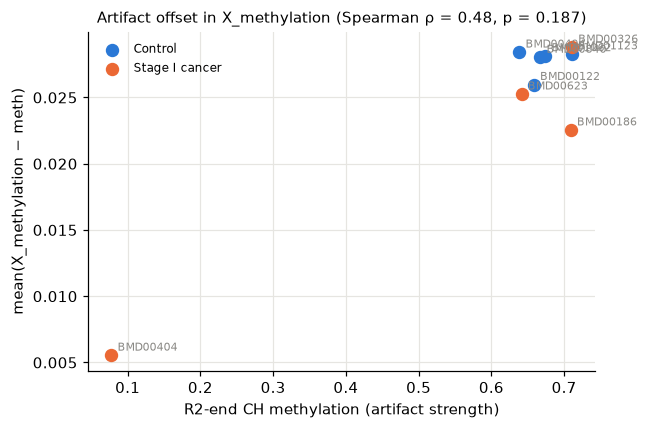

Mean offset: 0.0246 (range 0.0055 to 0.0288); median meth value: 0.0289


In [24]:
common = SETS["methylation"].columns.intersection(SETS["meth"].columns)
offset = (SETS["methylation"][common] - SETS["meth"][common]).mean(axis=1)
rho, p = stats.spearmanr(offset, samples["r2_end_ch_meth"])

fig, ax = plt.subplots(figsize=(6, 4))
for label in (0, 1):
    mask = (y == label).to_numpy()
    ax.scatter(samples["r2_end_ch_meth"][mask], offset[mask], s=60,
               color=CLASS_COLORS[label], label=CLASS_NAMES[label])
for sample_id in y.index:
    ax.annotate(sample_id, (samples.loc[sample_id, "r2_end_ch_meth"], offset[sample_id]),
                xytext=(4, 3), textcoords="offset points", fontsize=7, color=MUTED)
ax.set_xlabel("R2-end CH methylation (artifact strength)")
ax.set_ylabel("mean(X_methylation − meth)")
ax.set_title(f"Artifact offset in X_methylation (Spearman ρ = {rho:.2f}, p = {p:.3f})", fontsize=10)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

print(f"Mean offset: {offset.mean():.4f} (range {offset.min():.4f} to {offset.max():.4f}); "
      f"median meth value: {np.nanmedian(SETS['meth'].to_numpy()):.4f}")

### 3. Redundancy

For each pair of feature sets, the Spearman correlation across samples is computed region by region; the table shows its median over the shared regions. A set that correlates ~1 with `methylation` adds little new information; a set with low correlation is either new information or noise, which sections 4–5 tell apart.

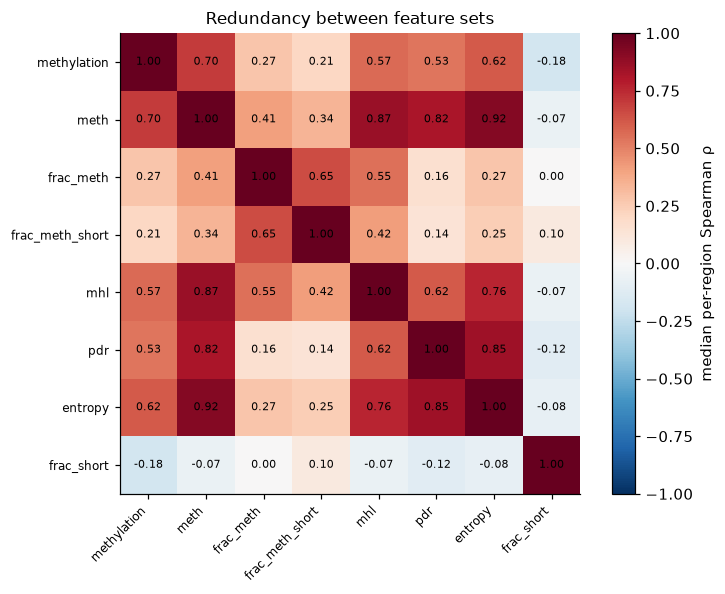

In [25]:
def median_region_correlation(A, B):
    shared = A.columns.intersection(B.columns)
    if len(shared) == 0:
        return np.nan
    r = A[shared].rank().corrwith(B[shared].rank())     # Spearman, region by region
    return float(np.nanmedian(r))

names = list(SETS)
redundancy = pd.DataFrame(
    [[median_region_correlation(SETS[a], SETS[b]) for b in names] for a in names],
    index=names, columns=names,
)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(redundancy.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(names)), names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(names)), names, fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{redundancy.iat[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.grid(False)
fig.colorbar(im, ax=ax, label="median per-region Spearman ρ")
ax.set_title("Redundancy between feature sets", fontsize=11)
fig.tight_layout()
plt.show()

### 4. Univariate signal against a permutation null

For each region, the AUC of the feature for cancer vs. control. A region is **strong** if its AUC is ≥ 0.9 or ≤ 0.1. By chance alone, many of ~2,400 regions are strong with so few samples, so the observed count is compared with the count for every other possible labelling of the samples (all C(9, 4) = 126 when the cohort is small, otherwise 1,000 random ones). The p-value is the share of labellings with at least as many strong regions as the real one; the true labelling is included, so the smallest possible p is 1/126 here.

In [26]:
STRONG = 0.4          # |AUC - 0.5| >= 0.4
MAX_EXACT = 2000
N_RANDOM = 1000

n1 = int(y.sum())
if comb(len(y), n1) <= MAX_EXACT:
    labelings = np.zeros((comb(len(y), n1), len(y)), dtype=bool)
    for i, idx in enumerate(combinations(range(len(y)), n1)):
        labelings[i, list(idx)] = True
else:
    rng = np.random.default_rng(SEED)
    labelings = np.array([rng.permutation(y.to_numpy()) for _ in range(N_RANDOM)], dtype=bool)

true_labels = y.to_numpy().astype(bool)
labelings = np.vstack([true_labels, labelings[~(labelings == true_labels).all(axis=1)]])

def auc_matrix(X, labelings):
    """AUC of every column for every labelling (rows), ignoring NaN (Mann-Whitney)."""
    ranks = X.rank().to_numpy()
    seen = ~np.isnan(ranks)
    ranks = np.nan_to_num(ranks)
    pos = labelings.astype(float)
    n_pos = pos @ seen
    n_neg = (1 - pos) @ seen
    rank_sum = pos @ ranks
    with np.errstate(invalid="ignore", divide="ignore"):
        return (rank_sum - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

rows, region_auc = [], {}
for name, X in {**SETS, "sample (fragment length)": X_sample}.items():
    auc = auc_matrix(X, labelings)
    strong = (np.abs(auc - 0.5) >= STRONG).sum(axis=1)
    region_auc[name] = pd.Series(auc[0], index=X.columns)
    rows.append({
        "feature_set": name,
        "n_features": X.shape[1],
        "strong_observed": int(strong[0]),
        "strong_null_mean": strong[1:].mean(),
        "strong_null_p95": np.percentile(strong[1:], 95),
        "signal_p": (strong >= strong[0]).mean(),
    })

signal = pd.DataFrame(rows).set_index("feature_set")
print(f"{len(labelings)} labellings (incl. the true one)")
signal.round(3)

126 labellings (incl. the true one)


,n_features,strong_observed,strong_null_mean,strong_null_p95,signal_p
feature_set,,,,,
methylation,2452,109,155.872,303.2,0.762
meth,2454,253,154.168,321.6,0.111
frac_meth,1369,19,15.384,30.4,0.230
frac_meth_short,32,0,0.056,0.8,1.000
mhl,2254,196,142.512,270.2,0.151
pdr,2149,163,135.224,284.2,0.190
entropy,2149,219,135.416,290.8,0.135
frac_short,2440,69,144.424,392.0,0.722
sample (fragment length),3,0,0.184,2.0,1.000


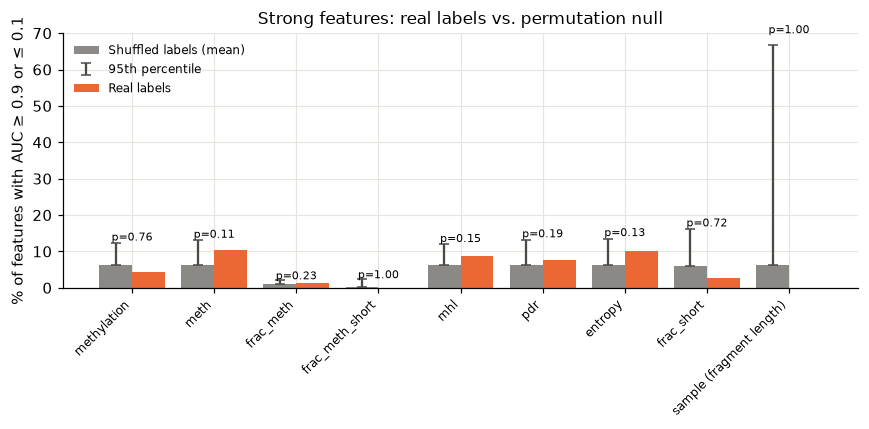

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(signal))
ratio_obs = signal["strong_observed"] / signal["n_features"] * 100
ratio_null = signal["strong_null_mean"] / signal["n_features"] * 100
ratio_p95 = signal["strong_null_p95"] / signal["n_features"] * 100

ax.bar(x - 0.2, ratio_null, width=0.4, color=MUTED, label="Shuffled labels (mean)")
ax.errorbar(x - 0.2, ratio_null, yerr=[np.zeros(len(x)), ratio_p95 - ratio_null],
            fmt="none", ecolor="#4a4945", capsize=3, label="95th percentile")
ax.bar(x + 0.2, ratio_obs, width=0.4, color=CLASS_COLORS[1], label="Real labels")
for xi, p in zip(x, signal["signal_p"]):
    ax.text(xi, max(ratio_obs.iloc[xi], ratio_p95.iloc[xi]) * 1.05, f"p={p:.2f}",
            ha="center", fontsize=7)
ax.set_xticks(x, signal.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("% of features with AUC ≥ 0.9 or ≤ 0.1")
ax.set_title("Strong features: real labels vs. permutation null", fontsize=11)
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

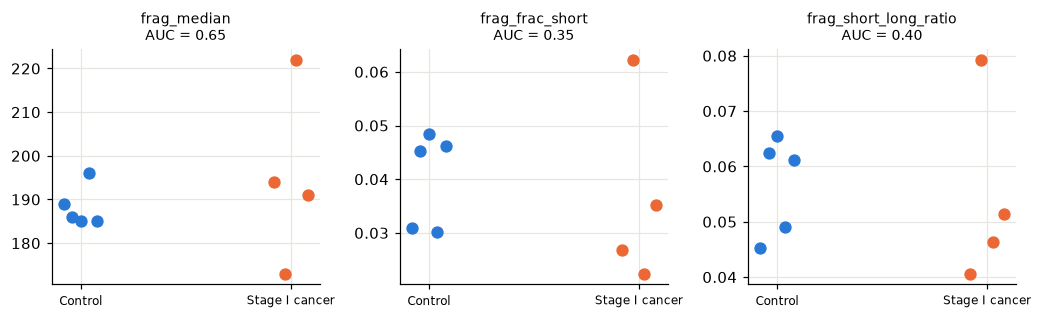

In [28]:
# Sample-level fragment features by class
fig, axes = plt.subplots(1, X_sample.shape[1], figsize=(3.2 * X_sample.shape[1], 3))
for ax, col in zip(np.atleast_1d(axes), X_sample.columns):
    for label in (0, 1):
        v = X_sample.loc[y == label, col]
        ax.scatter(np.full(len(v), label) + np.linspace(-0.08, 0.08, len(v)), v,
                   s=50, color=CLASS_COLORS[label])
    ax.set_xticks([0, 1], [CLASS_NAMES[0], CLASS_NAMES[1]], fontsize=8)
    ax.set_title(f"{col}\nAUC = {region_auc['sample (fragment length)'][col]:.2f}", fontsize=9)
fig.tight_layout()
plt.show()

### 5. Model impact (cross-validated)

The same rules as `02_ML_baseline.ipynb`: imputation, scaling and anything learned from the labels are fit inside the training folds only. Two models per feature set:

- **LogReg**: L2 logistic regression on all features of the set.
- **Outlier count**: the training **controls** define a mean and SD per region; a sample is summarised by the share of regions more than 3 SD above and below the controls (SD floored at its median, as 3–4 controls give unstable SDs). This turns thousands of features into two numbers, the usual way to pick up rare tumour signal, and needs no feature selection.

`auc_mean` is the out-of-fold AUC averaged over repeated stratified CV; `perm_p` compares it with the same CV on shuffled labels. `Dummy` shows where "no information" lands with this CV; with tiny folds it is not exactly 0.5.

In [29]:
class OutlierCount(BaseEstimator, TransformerMixin):
    """Share of regions above / below mean ± z·SD of the training controls."""

    def __init__(self, z=3.0):
        self.z = z

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        controls = X[np.asarray(y) == 0]
        self.mean_ = np.nanmean(controls, axis=0)
        sd = np.nanstd(controls, axis=0, ddof=1)
        self.sd_ = np.fmax(sd, np.nanmedian(sd[sd > 0]) if np.any(sd > 0) else 1.0)
        self.n_ = np.isfinite(self.mean_).sum()
        return self

    def transform(self, X):
        z = (np.asarray(X, dtype=float) - self.mean_) / self.sd_
        return np.c_[np.nansum(z > self.z, axis=1), np.nansum(z < -self.z, axis=1)] / self.n_


def logreg():
    return LogisticRegression(C=0.1, max_iter=5000, class_weight="balanced")

MODELS = {
    "LogReg": Pipeline([("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
                        ("scale", StandardScaler()), ("clf", logreg())]),
    "Outlier count": Pipeline([("outliers", OutlierCount()),
                               ("scale", StandardScaler()), ("clf", logreg())]),
}
DUMMY = Pipeline([("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
                  ("clf", DummyClassifier(strategy="prior"))])

CV_SETS = {**SETS, "sample (fragment length)": X_sample}
CV_SETS["methylation + frac_meth"] = pd.concat(
    [SETS["methylation"].add_prefix("meth04:"), SETS["frac_meth"].add_prefix("frac_meth:")], axis=1)
CV_SETS["all region sets"] = pd.concat(
    [X.add_prefix(f"{name}:") for name, X in SETS.items() if name != "methylation"], axis=1)

N_SPLITS = int(min(5, y.value_counts().min()))
N_REPEATS = 20
N_PERM = 40          # shuffled-label CV runs per set and model
N_PERM_REPEATS = 3

def cv_auc(model, X, labels, n_repeats, seed=SEED):
    """Mean over repeats of the pooled out-of-fold AUC."""
    aucs = []
    for r in range(n_repeats):
        cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed + r)
        prob = cross_val_predict(clone(model), X, labels, cv=cv, method="predict_proba")[:, 1]
        aucs.append(roc_auc_score(labels, prob))
    return np.array(aucs)

rng = np.random.default_rng(SEED)
null_labels = [rng.permutation(y.to_numpy()) for _ in range(N_PERM)]

def summarise(set_name, model_name, X, aucs):
    return {"feature_set": set_name, "model": model_name, "n_features": X.shape[1],
            "auc_mean": aucs.mean(), "auc_p2.5": np.percentile(aucs, 2.5),
            "auc_p97.5": np.percentile(aucs, 97.5)}

# Dummy ignores the features: one reference row
rows = [summarise("methylation", "Dummy", SETS["methylation"],
                  cv_auc(DUMMY, SETS["methylation"], y, N_REPEATS))]

with Parallel(n_jobs=-1) as parallel:
    for set_name, X in CV_SETS.items():
        for model_name, model in MODELS.items():
            aucs = cv_auc(model, X, y, N_REPEATS)
            null = np.array(parallel(
                delayed(cv_auc)(model, X, labels, N_PERM_REPEATS) for labels in null_labels
            )).mean(axis=1)
            row = summarise(set_name, model_name, X, aucs)
            row["perm_p"] = (1 + (null >= aucs.mean()).sum()) / (1 + N_PERM)
            rows.append(row)

cv_results = pd.DataFrame(rows).set_index(["feature_set", "model"])
print(f"CV: {N_SPLITS}-fold stratified x {N_REPEATS} repeats; null: {N_PERM} shuffles x {N_PERM_REPEATS} repeats")
cv_results.round(3)

CV: 4-fold stratified x 20 repeats; null: 40 shuffles x 3 repeats


n_features  auc_mean  auc_p2.5  \
feature_set              model                                           
methylation              Dummy                2452     0.425     0.425   
                         LogReg               2452     0.262     0.100   
                         Outlier count        2452     0.815     0.750   
meth                     LogReg               2454     0.635     0.550   
                         Outlier count        2454     0.508     0.424   
frac_meth                LogReg               1369     0.607     0.524   
                         Outlier count        1369     0.718     0.571   
frac_meth_short          LogReg                 32     0.785     0.624   
                         Outlier count          32     0.720     0.662   
mhl                      LogReg               2254     0.388     0.224   
                         Outlier count        2254     0.545     0.474   
pdr                      LogReg               2149     0.612     0.550   
                         Outlier count        2149     0.472     0.371   
entropy                  LogReg               2149     0.678     0.600   
                         Outlier count        2149     0.530     0.474   
frac_short               LogReg               2440     0.365     0.150   
                         Outlier count        2440     0.765     0.600   
sample (fragment length) LogReg                  3     0.200     0.024   
                         Outlier count           3     0.404     0.250   
methylation + frac_meth  LogReg               3821     0.490     0.350   
                         Outlier count        3821     0.815     0.750   
all region sets          LogReg              12847     0.420     0.250   
                         Outlier count       12847     0.580     0.500   

                                        auc_p97.5  perm_p  
feature_set              model                             
methylation              Dummy              0.425     NaN  
                         LogReg             0.402   0.732  
                         Outlier count      0.900   0.073  
meth                     LogReg             0.726   0.122  
                         Outlier count      0.550   0.512  
frac_meth                LogReg             0.700   0.244  
                         Outlier count      0.776   0.122  
frac_meth_short          LogReg             1.000   0.122  
                         Outlier count      0.850   0.146  
mhl                      LogReg             0.450   0.732  
                         Outlier count      0.650   0.439  
pdr                      LogReg             0.676   0.220  
                         Outlier count      0.550   0.561  
entropy                  LogReg             0.726   0.098  
                         Outlier count      0.600   0.463  
frac_short               LogReg             0.526   0.561  
                         Outlier count      0.900   0.098  
sample (fragment length) LogReg             0.452   0.829  
                         Outlier count      0.550   0.780  
methylation + frac_meth  LogReg             0.626   0.293  
                         Outlier count      0.900   0.073  
all region sets          LogReg             0.576   0.512  
                         Outlier count      0.600   0.268

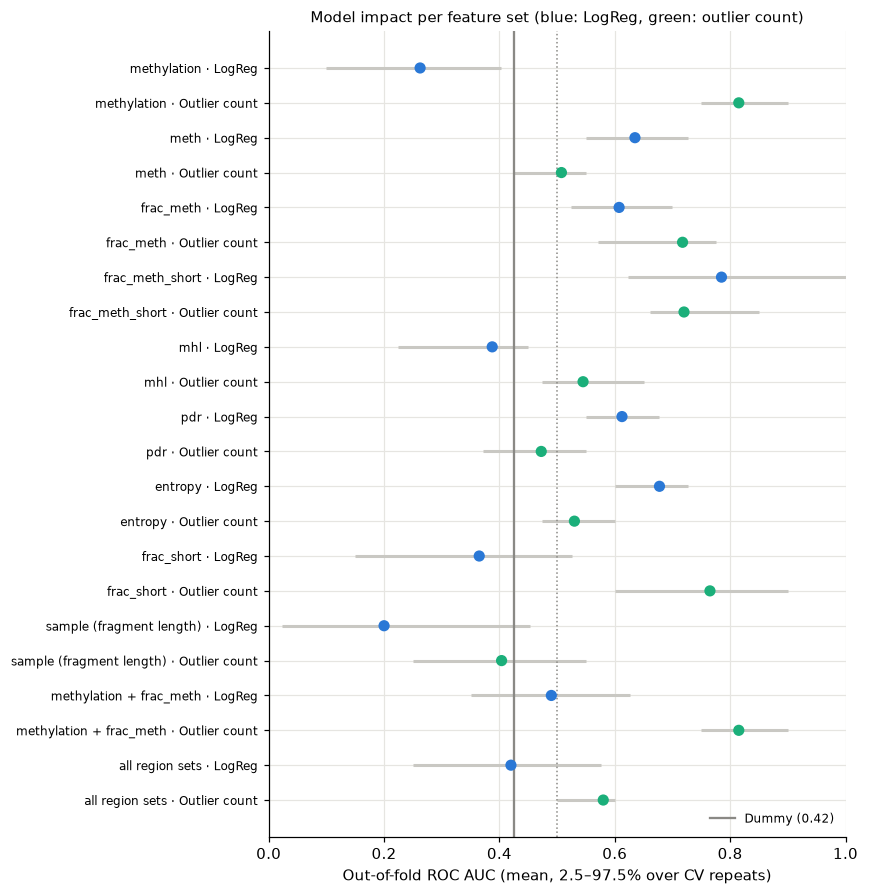

In [30]:
plot = cv_results.drop(index="Dummy", level="model").reset_index()
dummy_auc = cv_results.xs("Dummy", level="model")["auc_mean"].iloc[0]
labels = [f"{s} · {m}" for s, m in zip(plot["feature_set"], plot["model"])]
colors = [CLASS_COLORS[0] if m == "LogReg" else "#1baf7a" for m in plot["model"]]

fig, ax = plt.subplots(figsize=(8, 0.32 * len(plot) + 1.2))
yy = np.arange(len(plot))[::-1]
ax.errorbar(plot["auc_mean"], yy,
            xerr=[plot["auc_mean"] - plot["auc_p2.5"], plot["auc_p97.5"] - plot["auc_mean"]],
            fmt="none", ecolor="#c9c8c3", elinewidth=2, capsize=0)
ax.scatter(plot["auc_mean"], yy, c=colors, s=40, zorder=3)
ax.axvline(0.5, color=MUTED, linestyle=":", linewidth=1)
ax.axvline(dummy_auc, color=MUTED, linewidth=1.5, label=f"Dummy ({dummy_auc:.2f})")
ax.set_yticks(yy, labels, fontsize=8)
ax.set_xlim(0, 1)
ax.set_xlabel("Out-of-fold ROC AUC (mean, 2.5–97.5% over CV repeats)")
ax.set_title("Model impact per feature set (blue: LogReg, green: outlier count)", fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

### 6. Summary

One row per feature set. A useful set has:

- enough support (`missing_%` low, `median_support` well above the masking threshold),
- weak correlation with the technical variables (`rho_depth`, `rho_artifact`),
- more strong regions than the permutation null (`signal_p` small),
- a CV AUC above `Dummy` with a small `perm_p`,
- and, to add something new, a low correlation with `methylation`.

The tables are saved to `results/feature_eval/` so that runs on larger cohorts can be compared.

In [31]:
best_cv = (cv_results.drop(index="Dummy", level="model")
           .reset_index().sort_values("auc_mean", ascending=False)
           .groupby("feature_set").first()[["model", "auc_mean", "perm_p"]]
           .rename(columns={"model": "best_model", "auc_mean": "best_cv_auc", "perm_p": "best_perm_p"}))

summary = (
    quality[["regions_kept", "missing_%", "zero_%", "median_support"]]
    .join(confounding[["rho_depth", "rho_artifact", "rho_label"]], how="outer")
    .join(redundancy["methylation"].rename("rho_vs_methylation"), how="left")
    .join(signal[["strong_observed", "strong_null_mean", "signal_p"]], how="outer")
    .join(best_cv, how="outer")
)
summary = summary.loc[[i for i in [*SETS, "sample (fragment length)", *X_sample.columns,
                                   "methylation + frac_meth", "all region sets"] if i in summary.index]]

quality.to_csv(OUT_DIR / "quality.tsv", sep="\t")
confounding.to_csv(OUT_DIR / "confounding.tsv", sep="\t")
redundancy.to_csv(OUT_DIR / "redundancy.tsv", sep="\t")
signal.to_csv(OUT_DIR / "univariate_signal.tsv", sep="\t")
cv_results.to_csv(OUT_DIR / "cv_results.tsv", sep="\t")
summary.to_csv(OUT_DIR / "feature_set_summary.tsv", sep="\t")

summary.round(3)

,regions_kept,missing_%,zero_%,median_support,rho_depth,rho_artifact,rho_label,rho_vs_methylation,strong_observed,strong_null_mean,signal_p,best_model,best_cv_auc,best_perm_p
feature_set,,,,,,,,,,,,,,
methylation,2452.0,0.073,0.317,1311.5,-0.417,0.317,0.260,1.000,109.0,155.872,0.762,Outlier count,0.815,0.073
meth,2454.0,0.018,2.210,1252.0,-0.017,-0.067,0.693,0.700,253.0,154.168,0.111,LogReg,0.635,0.122
frac_meth,1369.0,0.219,71.539,163.0,-0.167,0.183,0.606,0.274,19.0,15.384,0.230,Outlier count,0.718,0.122
frac_meth_short,32.0,6.597,83.271,27.0,0.083,-0.033,0.520,0.209,0.0,0.056,1.000,LogReg,0.785,0.122
mhl,2254.0,0.315,1.479,151.0,-0.233,0.167,0.433,0.567,196.0,142.512,0.151,Outlier count,0.545,0.439
pdr,2149.0,0.455,1.865,143.0,0.233,-0.233,0.520,0.533,163.0,135.224,0.190,LogReg,0.612,0.220
entropy,2149.0,0.455,1.839,143.0,0.300,-0.300,0.520,0.617,219.0,135.416,0.135,LogReg,0.678,0.098
frac_short,2440.0,0.173,11.956,178.0,0.217,-0.350,-0.346,-0.183,69.0,144.424,0.722,Outlier count,0.765,0.098
sample (fragment length),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.184,1.000,Outlier count,0.404,0.780
